Available columns in the dataset:
Index(['GLORIA_ID', 'Organization_ID', 'Dataset_ID', 'Sample_ID',
       'LIMNADES_ID', 'LIMNADES_UID', 'SeaBASS_ID', 'Data_collection_purpose',
       'Special_event_flag', 'Site_name', 'Country', 'Country_code',
       'Latitude', 'Longitude', 'Date_Time_UTC', 'Water_body_type',
       'Water_type', 'Elevation_asl', 'Wave_height', 'Wind_speed',
       'Cloud_fraction', 'Depth', 'Platform', 'Distance_from_platform',
       'Platform_length', 'Platform_height', 'Distance_to_shore', 'Landcover',
       'Topography', 'Distance_to_river_discharge',
       'Optical_stability_of_water', 'Rain_event_hour',
       'Instrument_manufacturer', 'Instrument_model', 'Last_calibration',
       'Measurement_method', 'Lt_nadir', 'Lt_relative_azimuth', 'Lsky_zenith',
       'Lsky_relative_azimuth', 'Spectral_resolution', 'Number_of_radiometers',
       'Field_of_view_Lt_radiometer', 'Field_of_view_Lu_radiometer',
       'Skyglint_removal', 'Bias_removal_in_NIR', 'Self_

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,468 (9.64 KB)

 Trainable params: 2,468 (9.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1035.2778 - mae: 11.6405 - val_loss: 412.9343 - val_mae: 7.7539
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 517.4256 - mae: 9.1416 - val_loss: 411.9438 - val_mae: 7.7205
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 760.3309 - mae: 10.1302 - val_loss: 410.8056 - val_mae: 7.6844
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 753.7192 - mae: 10.6722 - val_loss: 409.5349 - val_mae: 7.6430
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1135.8781 - mae: 12.2343 - val_loss: 408.0121 - val_mae: 7.5935
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 895.9236 - mae: 11.2376 - val_loss: 406.2845 - val_mae: 7.5361
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 948.8782 - mae: 11.2461 - val_loss: 404.0781 - val_mae: 7.4632
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 785.1044 - mae: 10.7362 - val_loss: 401.2373 - val_mae: 7.3673
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/ste

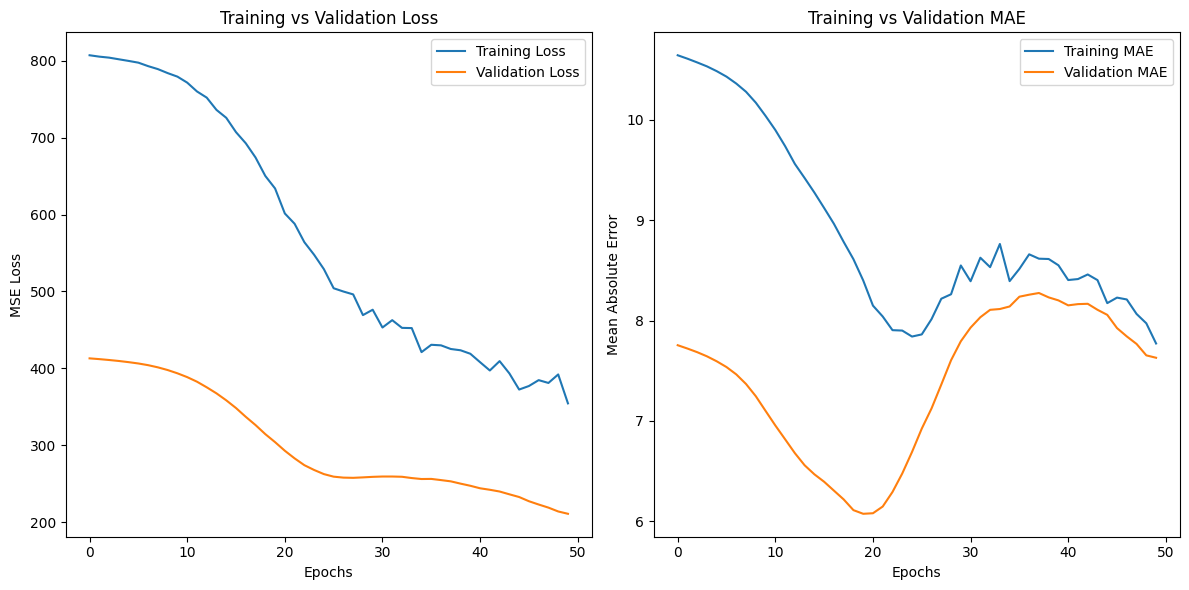

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ---------------------------
# Step 1: Load and Inspect Data
# ---------------------------

# File path to the GLORIA metadata file
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"

# Load the GLORIA metadata file
meta_data = pd.read_csv(meta_data_path)

# Display available columns in the dataset
print("Available columns in the dataset:")
print(meta_data.columns)

# ---------------------------
# Step 2: Select Features and Targets
# ---------------------------

# Define target variables (water quality parameters)
target_columns = ['aCDOM440', 'TSS', 'Chla_plus_phaeo', 'Secchi_depth']

# Define input features (spectral data or other valid columns)
feature_columns = ['Chla', 'TSS', 'aCDOM440']  # Replace with valid feature columns

# Check if all required columns are present in the dataset
missing_targets = [col for col in target_columns if col not in meta_data.columns]
missing_features = [col for col in feature_columns if col not in meta_data.columns]

if missing_targets:
    print(f"Missing target columns: {missing_targets}")
if missing_features:
    print(f"Missing feature columns: {missing_features}")

# Drop rows with missing values in selected columns
valid_columns = list(set(target_columns + feature_columns))
meta_data_cleaned = meta_data.dropna(subset=valid_columns)

# Extract features (X) and targets (y)
X = meta_data_cleaned[feature_columns].values  # Features
y = meta_data_cleaned[target_columns].values   # Targets

print(f"Shape of input features (X): {X.shape}")
print(f"Shape of target variables (y): {y.shape}")

# ---------------------------
# Step 3: Preprocess Data
# ---------------------------

# Normalize the input features to [0, 1]
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# ---------------------------
# Step 4: Build Neural Network Model
# ---------------------------

# Define input layer for features
input_layer = Input(shape=(X_train.shape[1],), name='input_layer')

# Add dense layers for feature extraction
dense1 = Dense(64, activation='relu')(input_layer)
dropout1 = Dropout(0.3)(dense1)
dense2 = Dense(32, activation='relu')(dropout1)

# Output layer for predicting multiple target variables (aCDOM440, TSS, Chla_plus_phaeo, Secchi_depth)
output_layer = Dense(y_train.shape[1], name='output_layer')(dense2)

# Define and compile the model
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

model.summary()

# ---------------------------
# Step 5: Train the Model
# ---------------------------

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.2)

print("\nTraining complete!")

# ---------------------------
# Step 6: Evaluate Model Performance
# ---------------------------

loss, mae = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss}, Test MAE: {mae}")

# ---------------------------
# Step 7: Visualize Training History
# ---------------------------

plt.figure(figsize=(12, 6))

# Plot Loss (MSE) over epochs
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs Validation Loss')

# Plot MAE over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training vs Validation MAE')

plt.tight_layout()
plt.show()


In [5]:
# Load Metadata File
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"
meta_data = pd.read_csv(meta_data_path)

# Load Spectral Reflectance Data (if in CSV format)
rrs_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_Rrs.csv"
rrs_data = pd.read_csv(rrs_data_path)

# Merge Metadata with Spectral Data
meta_data = pd.merge(meta_data, rrs_data, on='Sample_ID', how='inner')

# Select Features and Targets
feature_columns = ['Rrs_443', 'Rrs_560', 'Rrs_665']  # Spectral reflectance values
target_columns = ['aCDOM440', 'TSS', 'Chla_plus_phaeo', 'Secchi_depth']

meta_data_cleaned = meta_data.dropna(subset=feature_columns + target_columns)
X = meta_data_cleaned[feature_columns].values  # Features: Spectral Reflectance
y = meta_data_cleaned[target_columns].values   # Targets: Water Quality Parameters

# Preprocess Data
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

# Build Neural Network Model
input_layer = Input(shape=(X_train.shape[1],), name='input_layer')
dense1 = Dense(64, activation='relu')(input_layer)
dropout1 = Dropout(0.3)(dense1)
dense2 = Dense(32, activation='relu')(dropout1)
output_layer = Dense(y_train.shape[1], name='output_layer')(dense2)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train Model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.2)

# Evaluate Model Performance
loss, mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")


KeyError: 'Sample_ID'

In [6]:
import pandas as pd

# Load both datasets
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"
rrs_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_Rrs.csv"

meta_data = pd.read_csv(meta_data_path)
rrs_data = pd.read_csv(rrs_data_path)

# Print column names
print("Columns in meta_data:")
print(meta_data.columns)

print("\nColumns in rrs_data:")
print(rrs_data.columns)


Columns in meta_data:
Index(['GLORIA_ID', 'Organization_ID', 'Dataset_ID', 'Sample_ID',
       'LIMNADES_ID', 'LIMNADES_UID', 'SeaBASS_ID', 'Data_collection_purpose',
       'Special_event_flag', 'Site_name', 'Country', 'Country_code',
       'Latitude', 'Longitude', 'Date_Time_UTC', 'Water_body_type',
       'Water_type', 'Elevation_asl', 'Wave_height', 'Wind_speed',
       'Cloud_fraction', 'Depth', 'Platform', 'Distance_from_platform',
       'Platform_length', 'Platform_height', 'Distance_to_shore', 'Landcover',
       'Topography', 'Distance_to_river_discharge',
       'Optical_stability_of_water', 'Rain_event_hour',
       'Instrument_manufacturer', 'Instrument_model', 'Last_calibration',
       'Measurement_method', 'Lt_nadir', 'Lt_relative_azimuth', 'Lsky_zenith',
       'Lsky_relative_azimuth', 'Spectral_resolution', 'Number_of_radiometers',
       'Field_of_view_Lt_radiometer', 'Field_of_view_Lu_radiometer',
       'Skyglint_removal', 'Bias_removal_in_NIR', 'Self_shading_corr